1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

2. Load Dataset

In [9]:
matches = pd.read_csv("IPL_dataset/matches.csv")
deliveries = pd.read_csv("IPL_dataset/deliveries.csv")

print(matches.shape)
print(deliveries.shape)

matches.head()

(756, 18)
(150460, 21)


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


3. Basic Information

In [10]:
matches.info()
deliveries.info()

matches.isnull().sum()
deliveries.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

4. Number of Matches Per Season

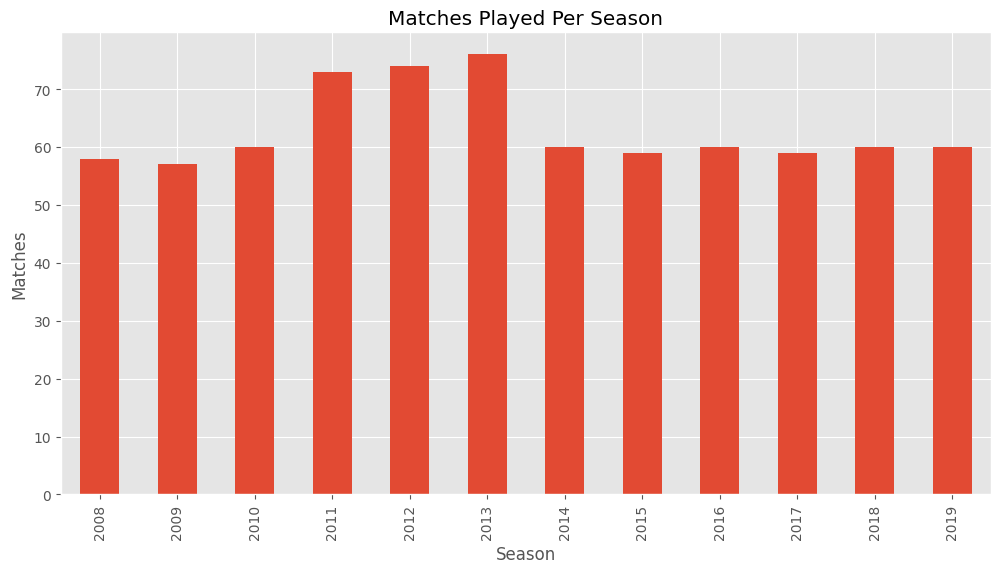

In [11]:
season_matches = matches.groupby('season')['id'].count()

plt.figure(figsize=(12,6))
season_matches.plot(kind='bar')
plt.title("Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.show()

5. Most Successful IPL Teams

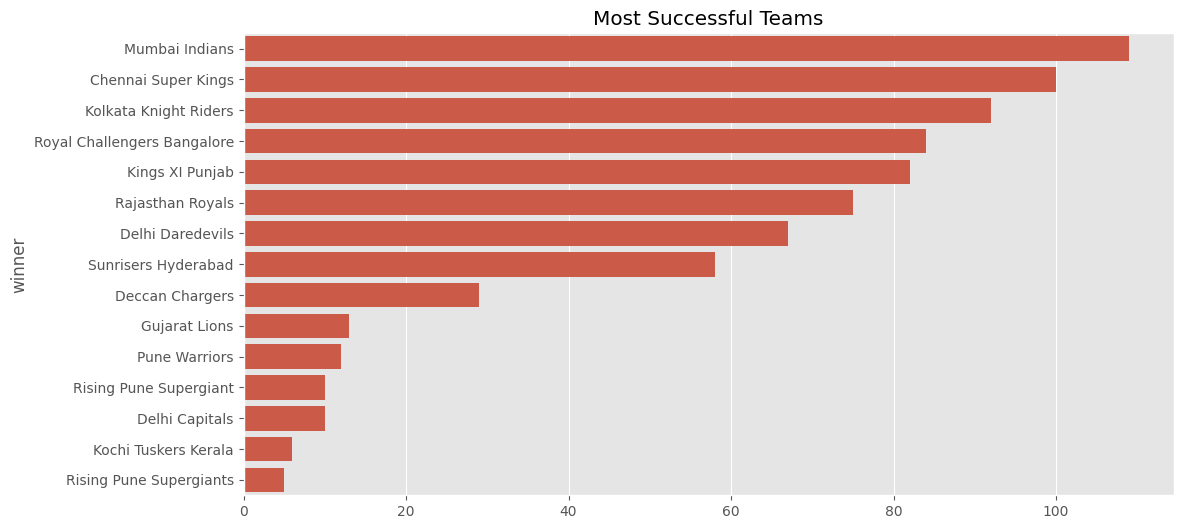

In [12]:
wins = matches['winner'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=wins.values,y=wins.index)
plt.title("Most Successful Teams")
plt.show()

6. Toss Winner Analysis

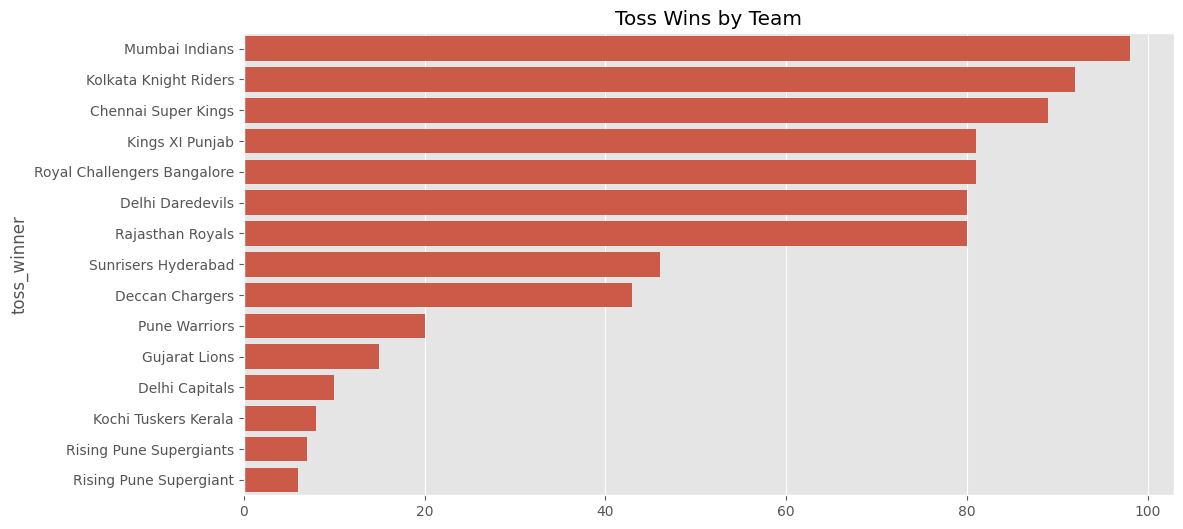

In [13]:
toss_wins = matches['toss_winner'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=toss_wins.values,y=toss_wins.index)
plt.title("Toss Wins by Team")
plt.show()

7. Toss Impact on Match Result

In [14]:
toss_match = (matches['toss_winner'] == matches['winner']).sum()

print("Matches where toss winner also won:",
      toss_match)

print("Percentage:",
      round((toss_match/len(matches))*100,2),"%")

Matches where toss winner also won: 393
Percentage: 51.98 %


8. Team Comparison (Wins)

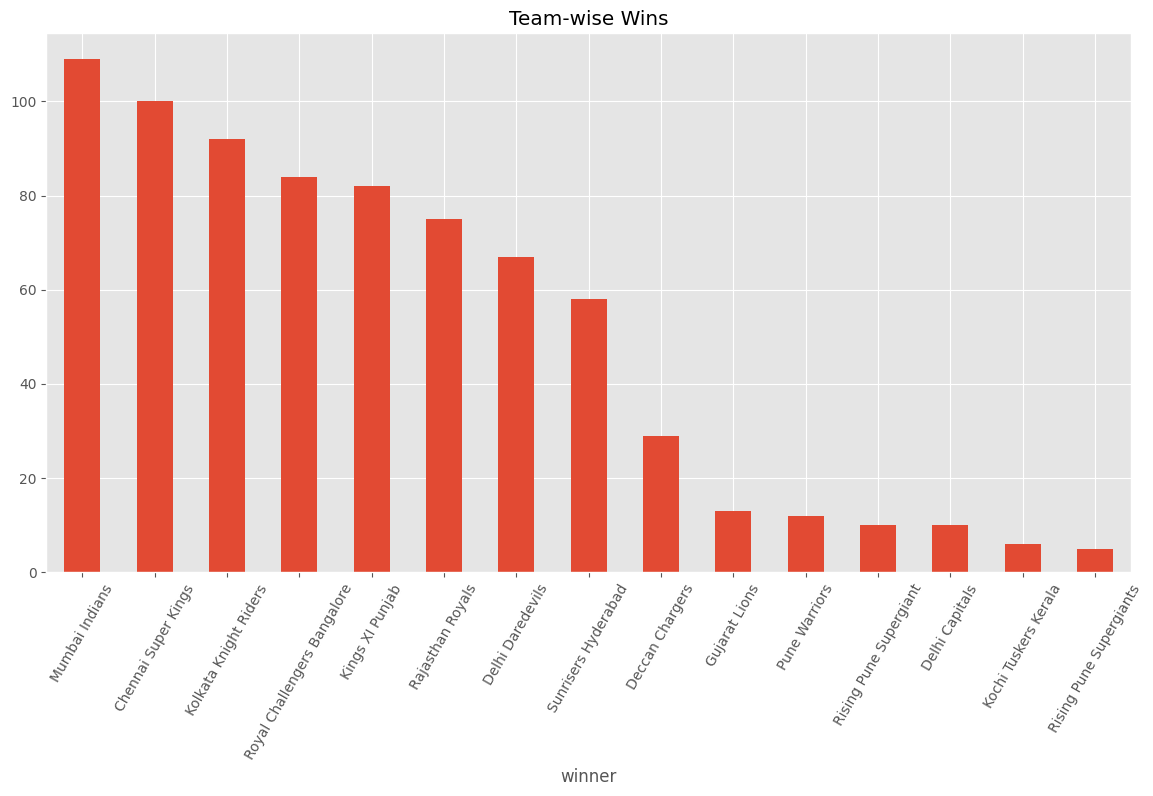

In [42]:
team_wins = matches['winner'].value_counts()

plt.figure(figsize=(14,7))
team_wins.plot(kind='bar')
plt.title("Team-wise Wins")
plt.xticks(rotation=60)
plt.show()

9. Top 10 Players of the Match

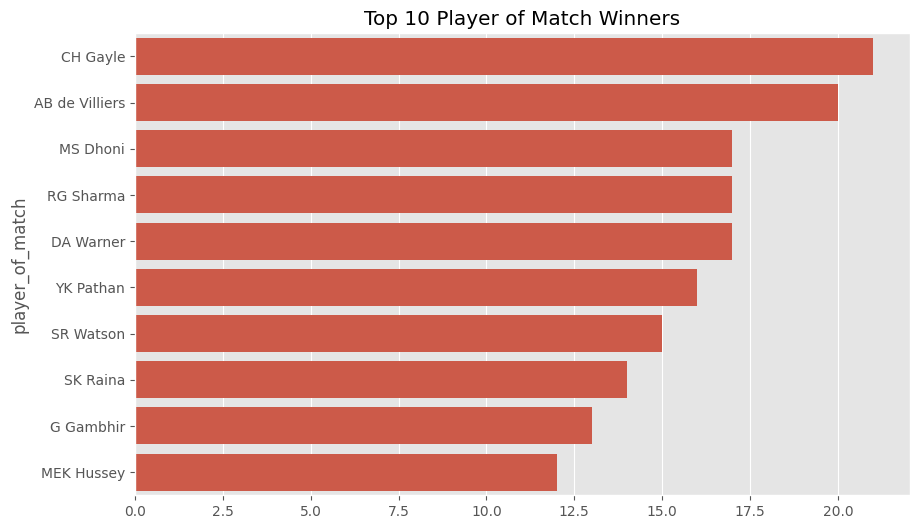

In [16]:
pom = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=pom.values,y=pom.index)
plt.title("Top 10 Player of Match Winners")
plt.show()

10. Top Run Scorers

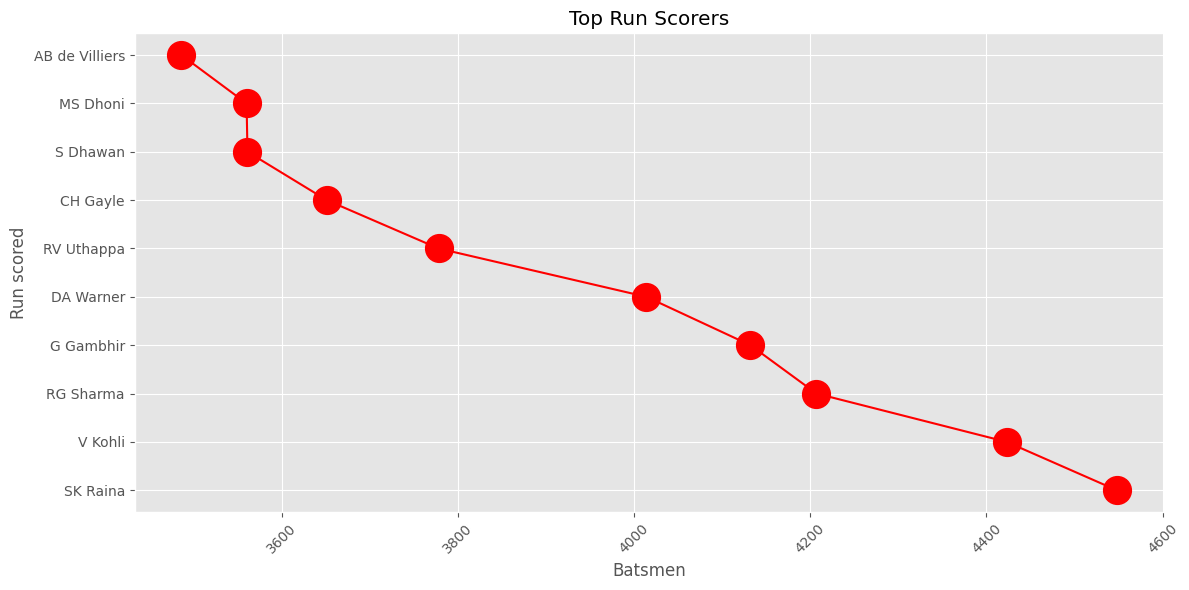

In [36]:
runs = deliveries.groupby('batsman')['batsman_runs'].sum()

top_runs = runs.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.plot(top_runs.values,top_runs.index, marker='o', color='red', ms=20)
plt.title("Top Run Scorers")
plt.xlabel('Batsmen')
plt.ylabel('Run scored')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

11. Orange Cap Style Analysis

In [18]:
orange = deliveries.groupby('batsman')['batsman_runs'].sum().reset_index()

orange.columns=['Batsman','Runs']

orange.sort_values('Runs',ascending=False).head(20)

,Batsman,Runs
374,SK Raina,4548
431,V Kohli,4423
323,RG Sharma,4207
137,G Gambhir,4132
103,DA Warner,4014
340,RV Uthappa,3778
85,CH Gayle,3651
347,S Dhawan,3561
259,MS Dhoni,3560
22,AB de Villiers,3486


12. Top Wicket Takers

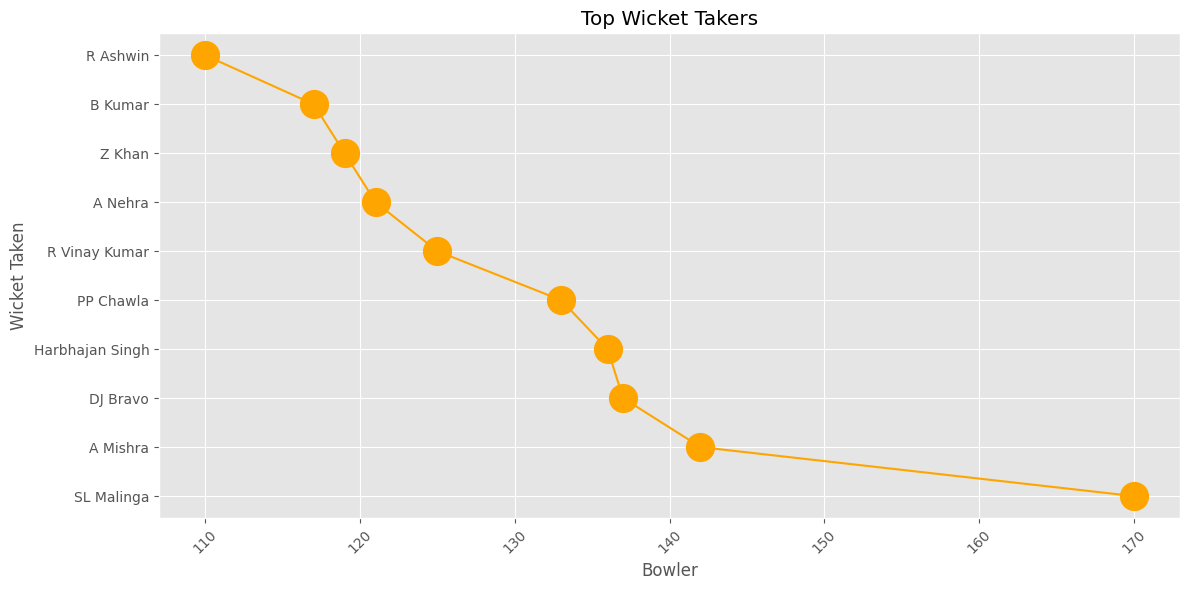

In [34]:
wickets = deliveries.dropna(subset=['player_dismissed'])

top_wickets = wickets['bowler'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.plot(top_wickets.values,top_wickets.index, marker='o', color='orange', ms=20)
plt.title("Top Wicket Takers")
plt.xlabel('Bowler')
plt.ylabel('Wicket Taken')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

13. Purple Cap Style Analysis

In [20]:
purple = wickets.groupby('bowler')['player_dismissed'].count()

purple.sort_values(ascending=False).head(20)

bowler
SL Malinga         170
A Mishra           142
DJ Bravo           137
Harbhajan Singh    136
PP Chawla          133
R Vinay Kumar      125
A Nehra            121
Z Khan             119
B Kumar            117
R Ashwin           110
SP Narine          109
UT Yadav           107
P Kumar            102
SR Watson          100
RP Singh           100
DW Steyn           100
PP Ojha             99
IK Pathan           99
JA Morkel           96
MM Sharma           91
Name: player_dismissed, dtype: int64

14. Highest Team Scores

In [21]:
team_scores = deliveries.groupby(
    ['match_id','inning','batting_team']
)['total_runs'].sum().reset_index()

top_scores = team_scores.sort_values(
    'total_runs',
    ascending=False
).head(10)

top_scores

,match_id,inning,batting_team,total_runs
829,411,1,Royal Challengers Bangalore,263
1250,620,1,Royal Challengers Bangalore,248
416,206,1,Chennai Super Kings,246
122,61,1,Chennai Super Kings,240
1134,562,1,Royal Challengers Bangalore,235
596,296,1,Kings XI Punjab,232
522,259,1,Delhi Daredevils,231
981,486,1,Kings XI Punjab,231
100,50,1,Kings XI Punjab,230
1170,580,1,Royal Challengers Bangalore,227


15. Most Sixes

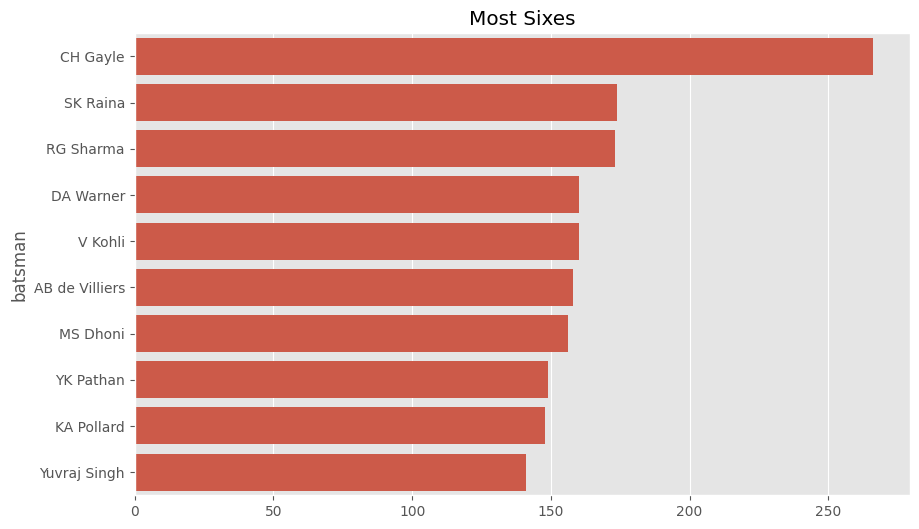

In [22]:
sixes = deliveries[deliveries['batsman_runs']==6]

top_sixes = sixes['batsman'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_sixes.values,y=top_sixes.index)
plt.title("Most Sixes")
plt.show()

16. Most Fours

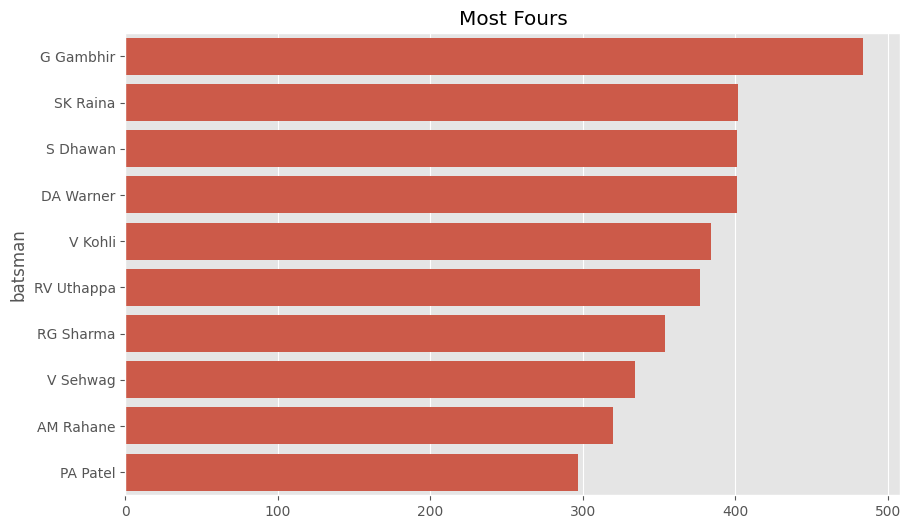

In [23]:
fours = deliveries[deliveries['batsman_runs']==4]

top_fours = fours['batsman'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_fours.values,y=top_fours.index)
plt.title("Most Fours")
plt.show()

17. Strike Rate Comparison

In [24]:
balls = deliveries.groupby('batsman')['ball'].count()

runs = deliveries.groupby('batsman')['batsman_runs'].sum()

strike_rate = ((runs/balls)*100)

strike_rate = strike_rate[runs>1000]

top_sr = strike_rate.sort_values(
    ascending=False
).head(15)

top_sr

batsman
GJ Maxwell        157.564103
V Sehwag          148.827059
AB de Villiers    145.129059
CH Gayle          144.194313
YK Pathan         140.751445
KA Pollard        140.621266
DA Warner         138.318401
DA Miller         137.709251
SK Raina          134.995548
SR Watson         134.838379
AC Gilchrist      133.054662
MS Dhoni          132.835821
DR Smith          132.279534
KP Pietersen      132.058047
ML Hayden         131.942789
dtype: float64

18. Economy Rate Comparison

In [25]:
runs_given = deliveries.groupby(
    'bowler'
)['total_runs'].sum()

balls_bowled = deliveries.groupby(
    'bowler'
)['ball'].count()

economy = (runs_given/(balls_bowled/6))

economy = economy[balls_bowled>500]

best_economy = economy.sort_values().head(15)

best_economy

bowler
SP Narine          6.395706
R Ashwin           6.490886
DW Steyn           6.600278
A Kumble           6.646999
M Muralitharan     6.698292
SL Malinga         6.757238
DL Vettori         6.833121
J Botha            6.922426
Harbhajan Singh    6.931415
S Nadeem           7.029024
B Kumar            7.039922
R Sharma           7.058824
DP Nannes          7.097242
MA Starc           7.107843
Shakib Al Hasan    7.115100
dtype: float64

19. Batting First vs Chasing

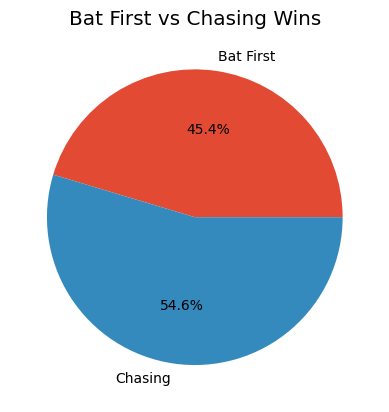

In [26]:
bat_first = matches[matches['win_by_runs']>0].shape[0]

chasing = matches[matches['win_by_wickets']>0].shape[0]

plt.pie(
    [bat_first,chasing],
    labels=['Bat First','Chasing'],
    autopct='%1.1f%%'
)

plt.title("Bat First vs Chasing Wins")
plt.show()

20. Venue Analysis

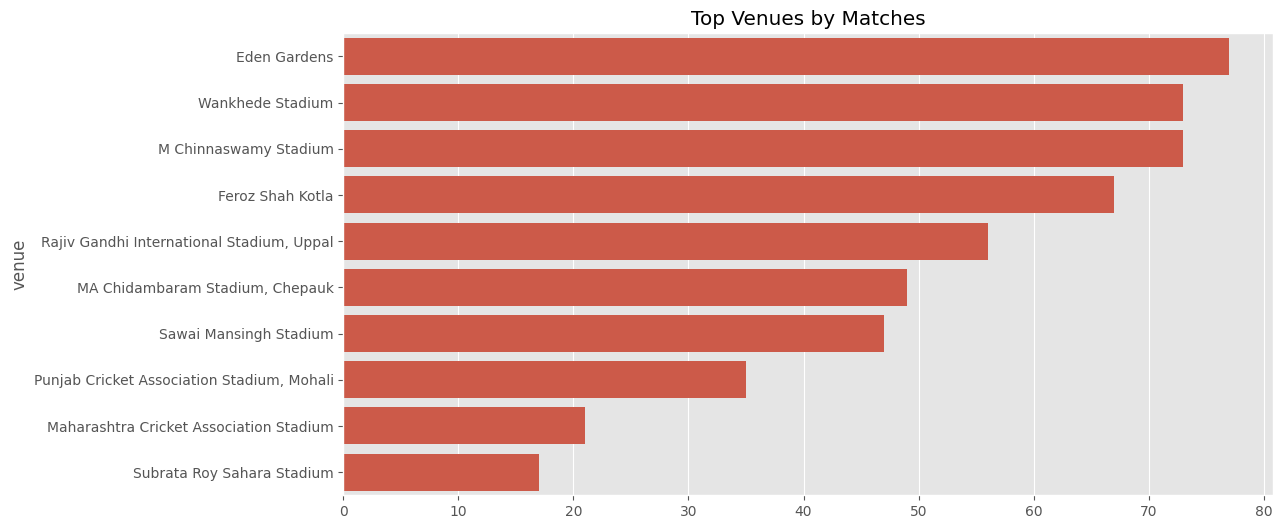

In [27]:
venue_matches = matches['venue'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=venue_matches.values,
            y=venue_matches.index)

plt.title("Top Venues by Matches")
plt.show()

21. Team Head-to-Head Comparison

Example: MI vs CSK

In [28]:
mi_csk = matches[
    ((matches['team1']=='Mumbai Indians') &
     (matches['team2']=='Chennai Super Kings')) |
    ((matches['team1']=='Chennai Super Kings') &
     (matches['team2']=='Mumbai Indians'))
]

mi_csk['winner'].value_counts()

winner
Mumbai Indians         17
Chennai Super Kings    11
Name: count, dtype: int64

22. Season-wise Champions

In [29]:
champions = matches.groupby(
    'season'
).tail(1)[['season','winner']]

champions

,season,winner
58,2017,Mumbai Indians
116,2008,Rajasthan Royals
173,2009,Deccan Chargers
233,2010,Chennai Super Kings
306,2011,Chennai Super Kings
380,2012,Kolkata Knight Riders
456,2013,Mumbai Indians
516,2014,Kolkata Knight Riders
575,2015,Mumbai Indians
635,2016,Sunrisers Hyderabad


23. Death Overs Analysis (Overs 16-20)

In [30]:
death = deliveries[deliveries['over']>=16]

death_runs = death.groupby(
    'batsman'
)['batsman_runs'].sum()

death_runs.sort_values(
    ascending=False
).head(15)

batsman
MS Dhoni          2076
KA Pollard        1352
RG Sharma         1314
AB de Villiers    1203
V Kohli            993
YK Pathan          930
Yuvraj Singh       883
JP Duminy          869
SK Raina           767
RA Jadeja          753
KD Karthik         704
AT Rayudu          703
DJ Bravo           686
DA Miller          672
IK Pathan          663
Name: batsman_runs, dtype: int64

24. Team Run Comparison

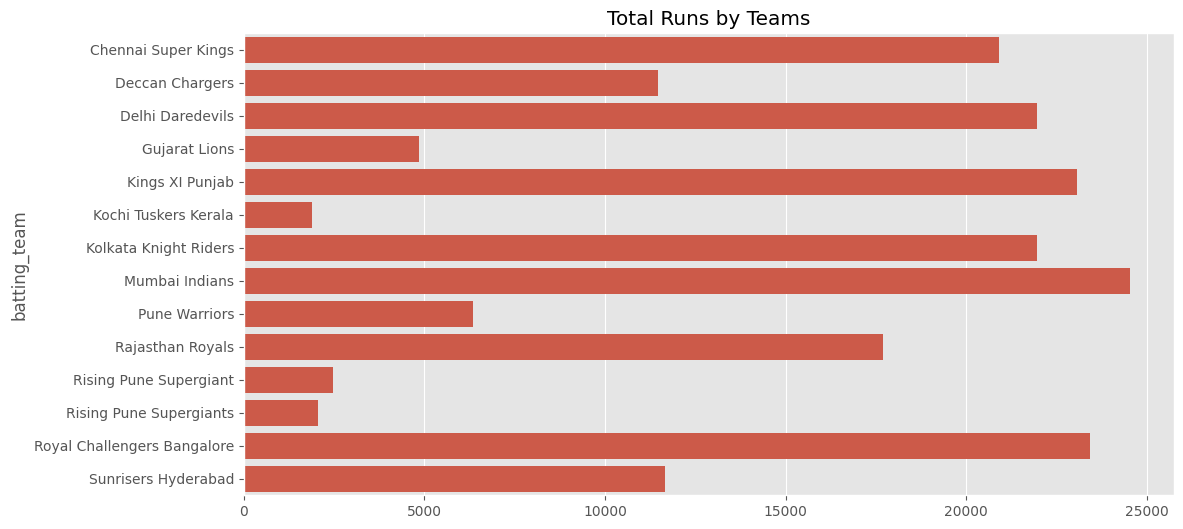

In [31]:
team_runs = deliveries.groupby(
    'batting_team'
)['total_runs'].sum()

plt.figure(figsize=(12,6))
sns.barplot(x=team_runs.values,
            y=team_runs.index)

plt.title("Total Runs by Teams")
plt.show()

25. Final Correlation Analysis

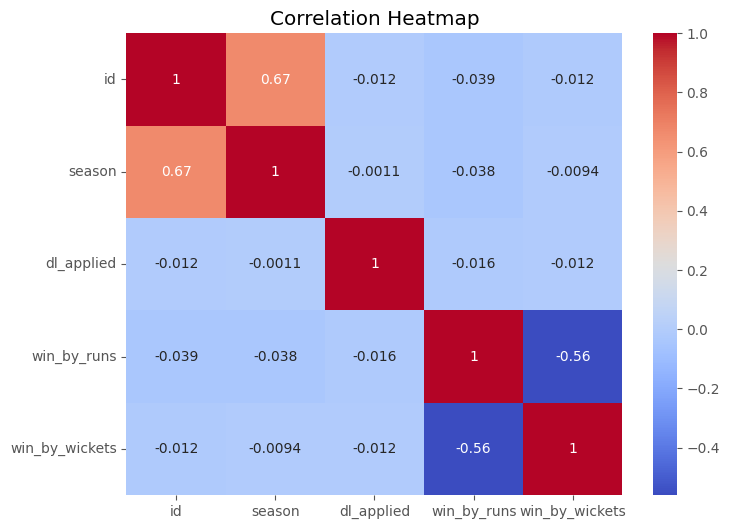

In [32]:
numeric_cols = matches.select_dtypes(
    include=np.number
)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()